# **Business Case and Details**

## **Business Case: Skin Disorder Prediction**

Skin disorders like psoriasis, seborrheic dermatitis, lichen planus, pityriasis rosea, chronic dermatitis, and pityriasis rubra pilaris share overlapping clinical symptoms such as erythema and scaling. These similarities often lead to diagnostic challenges, especially in the early stages when the disease may mimic others.

Traditionally, diagnosis requires:
* Clinical examination
* Histopathological evaluation via biopsy
* Expert medical judgment

However, similar visual and microscopic characteristics make accurate diagnosis difficult. A machine learning–based approach helps in:
* Early detection
* Reducing unnecessary biopsies
* Supporting doctors with reliable predictions
* Classifying patients into correct disease categories



## **Dataset Summary**

Total Attributes: 34

* 12 clinical attributes
* 22 histopathological attributes

Target: 6 skin disease classes

Feature values:

* Most attributes take values 0–3 (degree of severity)

* Family history is binary

* Age is continuous

Diagnosis Difficulty:

* Overlapping symptoms and biopsy results
* Diseases evolve and show mixed characteristics at early stages

This project uses these attributes to classify the correct skin disease earliest to doctor.

In [1]:
import numpy as np
import pandas as pd


In [2]:
data=pd.read_csv("skin.csv")

In [3]:
data

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


In [4]:
data["class"].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

In [5]:
pd.set_option('display.max_columns',None)

In [6]:
data

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,0,2,2,0,0,3,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,0,2,0,0,0,3,2,0,0,0,0,0,0,0,3,0,2,0,1,0,0,2,3,50,3


In [7]:
data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

# here the age is should be of int but bcz of presence of ? it is given as object so we need to change it

In [9]:
data.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,0.125683,0.404372,0.139344,0.546448,0.336066,1.368852,1.956284,0.527322,1.289617,0.663934,0.991803,0.633880,0.295082,0.363388,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,0.331946,0.869818,0.411790,0.815451,0.853139,1.104418,0.712512,0.757116,0.917562,1.056829,1.162161,1.034924,0.670578,0.759721,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [10]:
data.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

# here no missing value are found

In [11]:
data['Age'].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

## "Since the Age column contained '?'we replaced those '?' entries with the median age value.

In [12]:
data['Age'] = data['Age'].replace('?', np.nan)

In [13]:
data['Age'] = pd.to_numeric(data['Age'])

In [14]:
data['Age'] = data['Age'].fillna(data['Age'].median())

# Exploratory Data Analysis

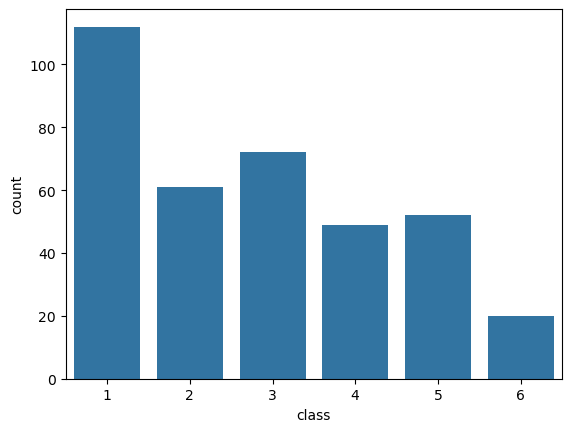

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='class', data=data)
plt.show()

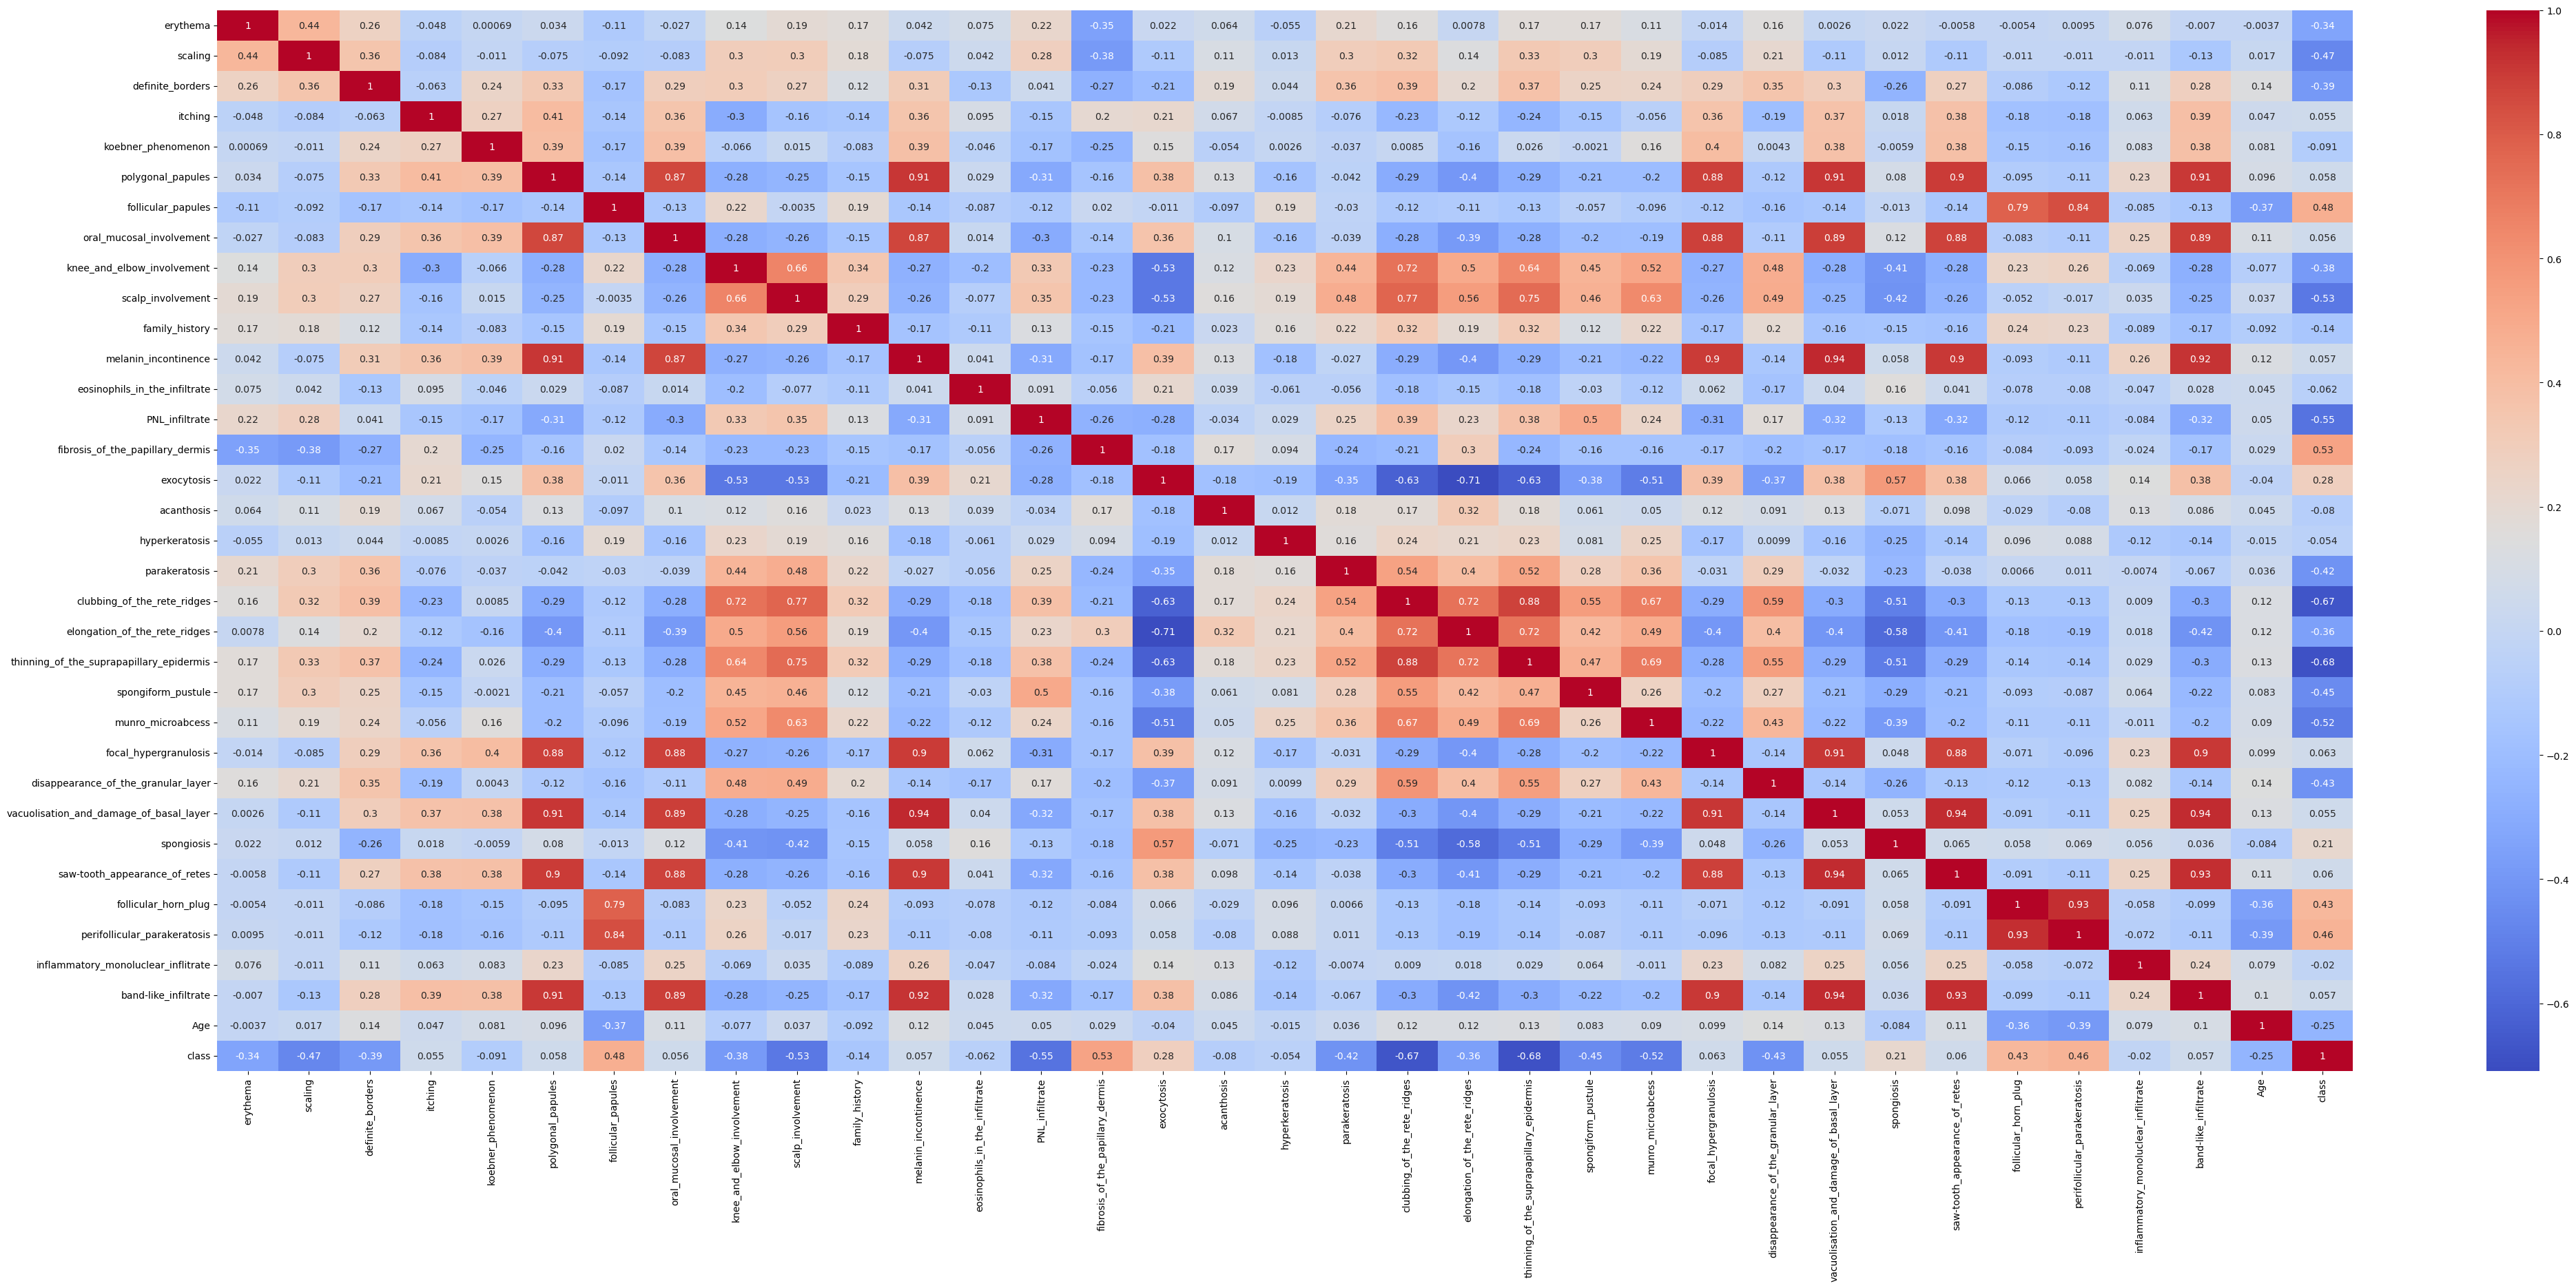

In [16]:
plt.figure(figsize=(50,20))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True)
plt.show()

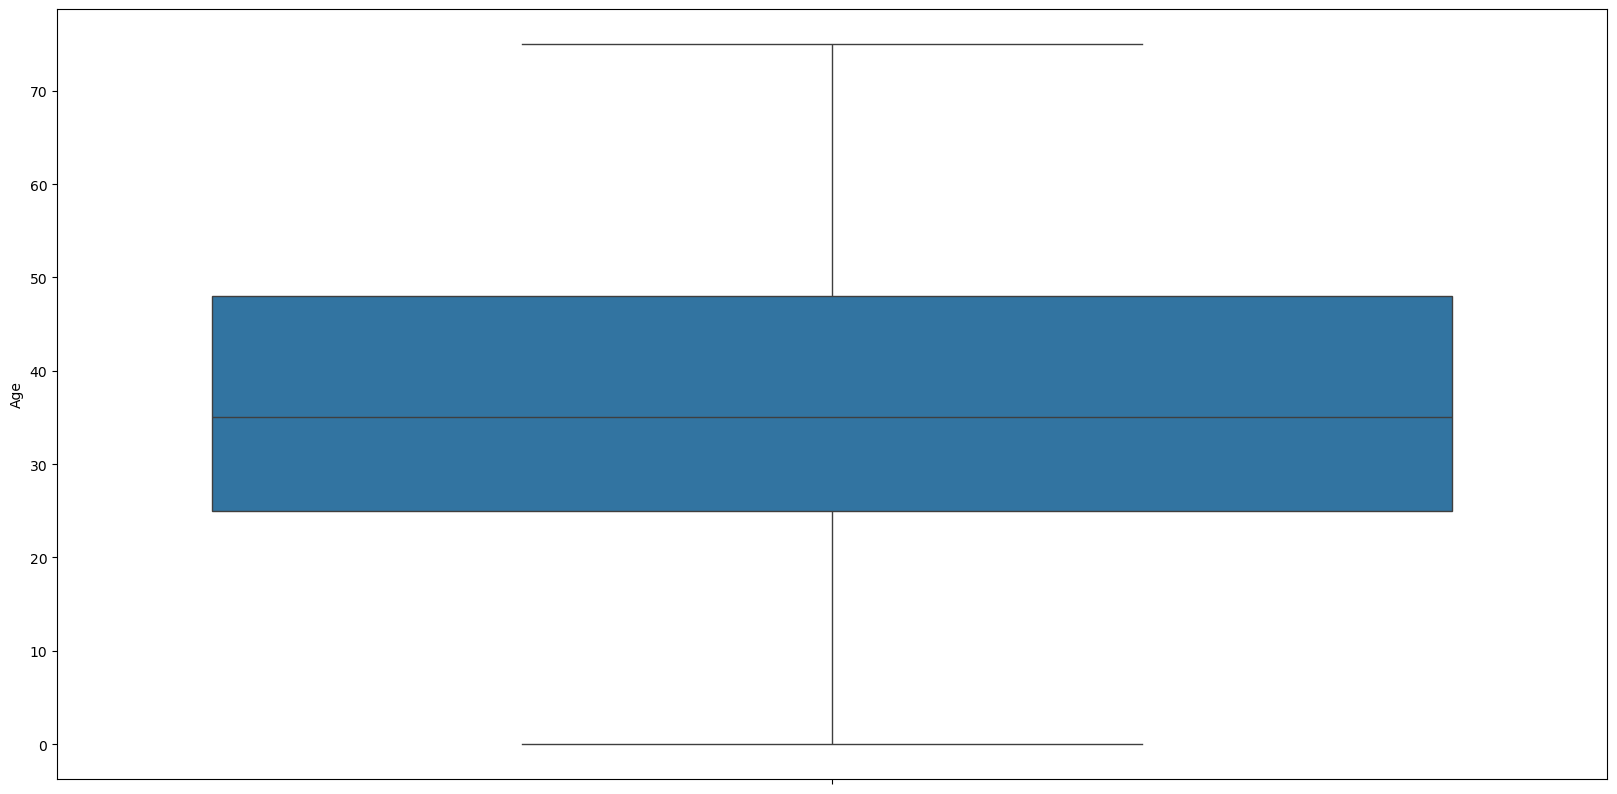

In [17]:
plt.figure(figsize=(20,10))
sns.boxplot(y=data['Age'])
plt.xticks(rotation=90)
plt.show()

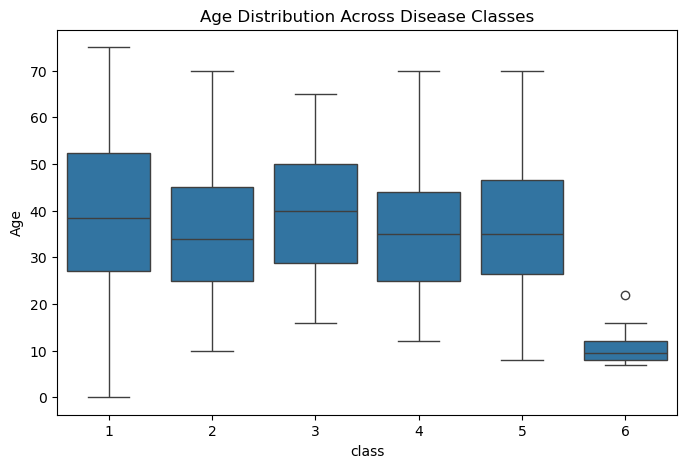

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='class', y='Age', data=data)
plt.title("Age Distribution Across Disease Classes")
plt.show()

In [19]:
X = data.drop('class', axis=1)
y = data['class']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [21]:
from imblearn.over_sampling import SMOTE # assign SMOTE for balancing data
sm = SMOTE()

In [23]:
x_smote,y_smote = sm.fit_resample(X_train,y_train)

In [24]:
from collections import Counter  # checking either data balanced or not
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_smote))

Actual Classes Counter({1: 81, 3: 59, 2: 52, 5: 42, 4: 41, 6: 17})
SMOTE Classes Counter({5: 81, 2: 81, 1: 81, 4: 81, 3: 81, 6: 81})


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

lr = LogisticRegression(max_iter=5000)

lr.fit(x_smote, y_smote)

pred_lr = lr.predict(X_test)

print(classification_report(y_test,pred_lr))   # classification report where every type of score show

              precision    recall  f1-score   support

           1       1.00      0.97      0.98        31
           2       0.82      1.00      0.90         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       0.67      0.67      0.67         3

    accuracy                           0.96        74
   macro avg       0.91      0.92      0.91        74
weighted avg       0.96      0.96      0.96        74



In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_smote, y_smote)

pred_dt = dt.predict(X_test)

print(classification_report(y_test,pred_dt))    # classification report where every type of score show

              precision    recall  f1-score   support

           1       1.00      0.94      0.97        31
           2       0.82      1.00      0.90         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.97        74
   macro avg       0.97      0.99      0.98        74
weighted avg       0.98      0.97      0.97        74



In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150)

rf.fit(x_smote, y_smote)

pred_rf = rf.predict(X_test)

print(classification_report(y_test,pred_rf))    # classification report where every type of score show

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_smote, y_smote)

pred_knn = knn.predict(X_test)

print(classification_report(y_test,pred_knn))   # classification report where every type of score show

              precision    recall  f1-score   support

           1       1.00      0.84      0.91        31
           2       0.55      0.67      0.60         9
           3       1.00      1.00      1.00        13
           4       0.55      0.75      0.63         8
           5       0.89      0.80      0.84        10
           6       0.50      0.67      0.57         3

    accuracy                           0.82        74
   macro avg       0.75      0.79      0.76        74
weighted avg       0.86      0.82      0.84        74



In [32]:
# Support Vector Classifier Model

from sklearn.svm import SVC
svc = SVC(random_state=10) ## base model with default parameters
svc.fit(x_smote, y_smote)
pred_svc = svc.predict(X_test)  # predict the model
print(classification_report(y_test,pred_svc))

              precision    recall  f1-score   support

           1       1.00      0.94      0.97        31
           2       0.50      0.67      0.57         9
           3       1.00      1.00      1.00        13
           4       0.29      0.25      0.27         8
           5       1.00      0.90      0.95        10
           6       0.50      0.67      0.57         3

    accuracy                           0.82        74
   macro avg       0.71      0.74      0.72        74
weighted avg       0.84      0.82      0.83        74



In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVC'],

    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_svc)
    ],

    'F1 Score': [
        f1_score(y_test, pred_lr, average='weighted'),
        f1_score(y_test, pred_dt, average='weighted'),
        f1_score(y_test, pred_rf, average='weighted'),
        f1_score(y_test, pred_knn, average='weighted'),
        f1_score(y_test, pred_svc, average='weighted')
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.959459  0.960250
1        Decision Tree  0.972973  0.973874
2        Random Forest  0.986486  0.986392
3                  KNN  0.824324  0.836063
4                  SVC  0.824324  0.830146


# Model Comparison Conclusion

Five machine learning models were evaluated using Accuracy and F1 Score: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Classifier (SVC). Among all the models, Random Forest achieved the best performance with an Accuracy of 98.65% and an F1 Score of 98.64%, indicating excellent predictive capability and balanced classification across all classes. Decision Tree was the second-best model with an accuracy of 97.30%, followed by Logistic Regression with 95.95%. In contrast, KNN and SVC produced comparatively lower performance, each achieving an accuracy of 82.43%. Based on the comparison, Random Forest was selected as the final model because it provided the highest accuracy and F1 score, making it the most reliable and effective classifier for this multiclass classification problem.

## Model Findings

Patients showing high levels of erythema, scaling, well-defined borders, itching, knee and elbow involvement, scalp involvement, PNL infiltrate, acanthosis, hyperkeratosis, parakeratosis, clubbing and elongation of rete ridges, thinning of the suprapapillary epidermis, spongiform pustules, Munro microabscesses, disappearance of the granular layer, and inflammatory mononuclear infiltrate are more likely to be classified as Class 1 (Psoriasis).

# Report on Challenges faced
The skin disease dataset contains 366 records and 35 columns, with mostly integer-type features. The main challenge was understanding the relationships between the clinical features and the target classes. Extracting meaningful insights from the data required careful analysis during the initial stage. Once the data was well understood, preprocessing, model building, and evaluation were completed without major difficulties.